
Running Direct Two-Sum LWM for Pe=1, nu=1


/tmp/ipykernel_2456/1704243333.py:417: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l2_error = np.sqrt(np.trapz(abs_error ** 2, x_dense))


Pe                         = 1
nu                         = 1
J cells                    = 4
M modes/cell               = 6
Unknowns J*M               = 24
Condition number cond(A)   = 2.9494e+04
Algebraic residual ||Ac-b||inf = 2.2204e-16

Dense-grid error metrics
Maximum absolute error     = 1.0563e-09
Mean absolute error        = 1.4850e-10
RMS error                  = 2.8209e-10
L2-type error              = 4.3412e-10
Left boundary error        = 1.1102e-16
Right boundary error       = 5.4216e-18
Max dense differential residual = 3.2497e-06

Table: LWM vs Exact
x              LWM solution          Exact solution        Absolute error
 0.0000000000      1.000000000000e+00      1.000000000000e+00      1.1102e-16
 0.1000000000      9.387929751202e-01      9.387929754399e-01      3.1972e-10
 0.2000000000      8.711487522156e-01      8.711487519142e-01      3.0143e-10
 0.3000000000      7.963903237099e-01      7.963903232977e-01      4.1222e-10
 0.4000000000      7.137694816708e-01     

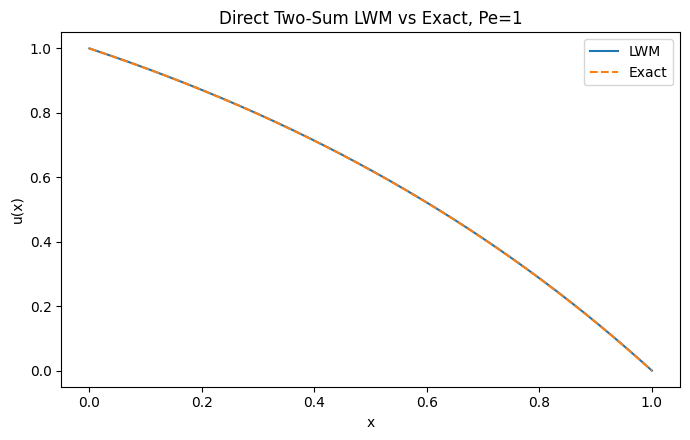

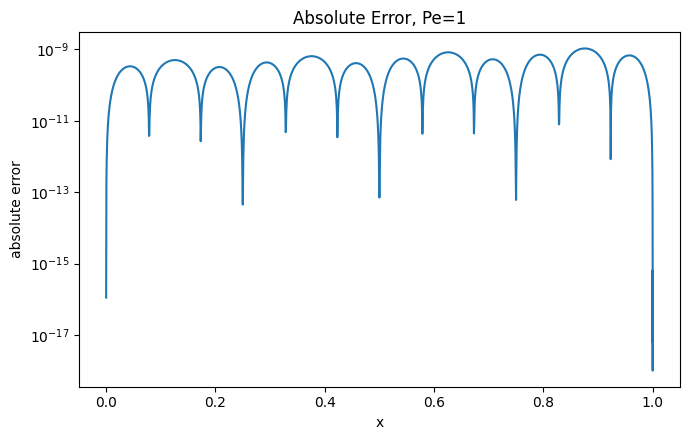


Running Direct Two-Sum LWM for Pe=10, nu=0.1
Pe                         = 10
nu                         = 0.1
J cells                    = 8
M modes/cell               = 6
Unknowns J*M               = 48
Condition number cond(A)   = 3.2430e+05
Algebraic residual ||Ac-b||inf = 1.4211e-14

Dense-grid error metrics
Maximum absolute error     = 6.3265e-06
Mean absolute error        = 3.7786e-07
RMS error                  = 1.1165e-06
L2-type error              = 1.3122e-06
Left boundary error        = 0.0000e+00
Right boundary error       = 3.6253e-18
Max dense differential residual = 7.9978e-02

Table: LWM vs Exact
x              LWM solution          Exact solution        Absolute error
 0.0000000000      1.000000000000e+00      1.000000000000e+00      0.0000e+00
 0.1000000000      9.999219869789e-01      9.999219865839e-01      3.9500e-10
 0.2000000000      9.997099209672e-01      9.997099241324e-01      3.1653e-09
 0.3000000000      9.991334707225e-01      9.991334786242e-01      7.90

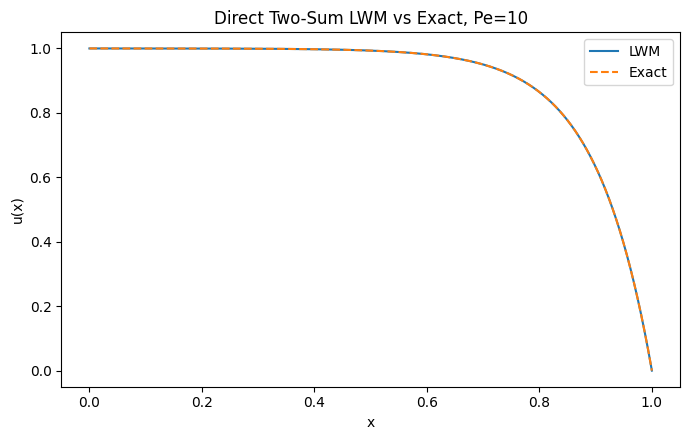

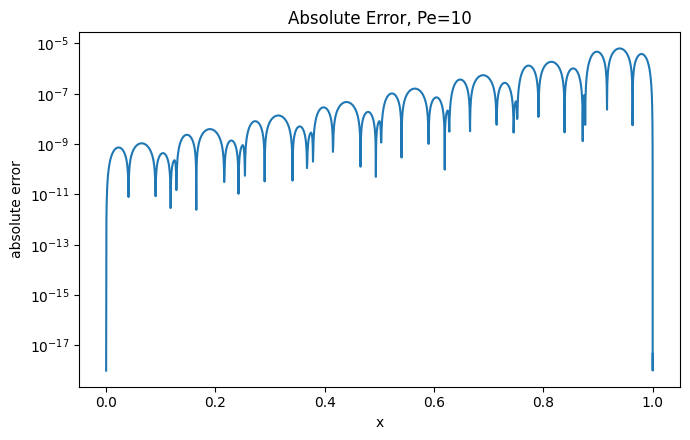


Running Direct Two-Sum LWM for Pe=100, nu=0.01
Pe                         = 100
nu                         = 0.01
J cells                    = 40
M modes/cell               = 6
Unknowns J*M               = 240
Condition number cond(A)   = 4.4585e+07
Algebraic residual ||Ac-b||inf = 9.0949e-13

Dense-grid error metrics
Maximum absolute error     = 2.2131e-04
Mean absolute error        = 8.3967e-06
RMS error                  = 3.2181e-05
L2-type error              = 2.0210e-05
Left boundary error        = 0.0000e+00
Right boundary error       = 1.7738e-16
Max dense differential residual = 7.4312e+01

Table: LWM vs Exact
x              LWM solution          Exact solution        Absolute error
 0.0000000000      1.000000000000e+00      1.000000000000e+00      0.0000e+00
 0.1000000000      1.000000000000e+00      1.000000000000e+00      0.0000e+00
 0.2000000000      1.000000000000e+00      1.000000000000e+00      0.0000e+00
 0.3000000000      1.000000000000e+00      1.000000000000e+00    

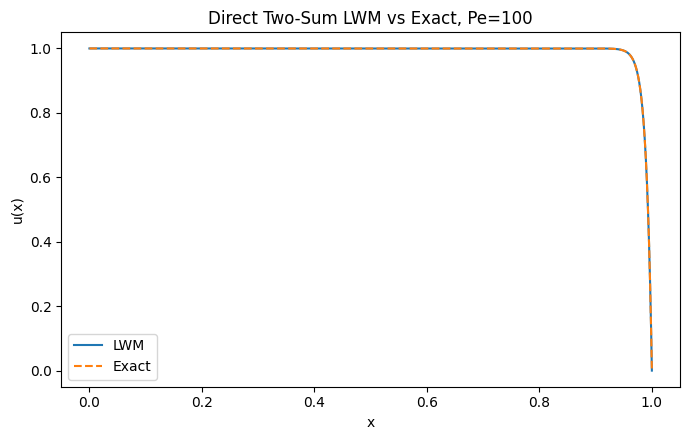

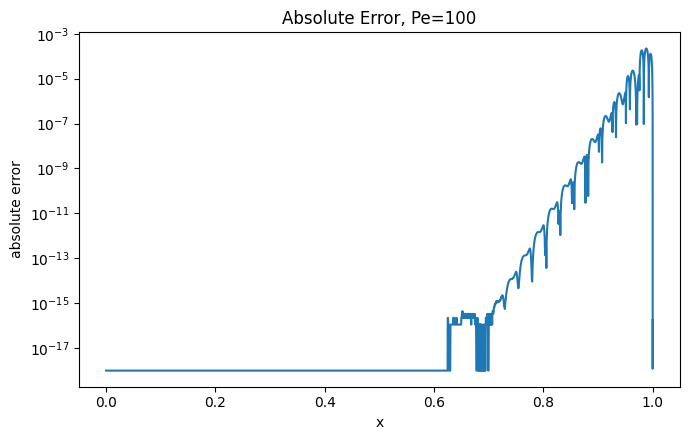


Running Direct Two-Sum LWM for Pe=1000, nu=0.001
Pe                         = 1000
nu                         = 0.001
J cells                    = 200
M modes/cell               = 6
Unknowns J*M               = 1200
Condition number cond(A)   = 5.8787e+09
Algebraic residual ||Ac-b||inf = 2.9104e-11

Dense-grid error metrics
Maximum absolute error     = 4.7352e-03
Mean absolute error        = 1.7083e-04
RMS error                  = 6.7575e-04
L2-type error              = 2.0060e-04
Left boundary error        = 0.0000e+00
Right boundary error       = 7.8063e-17
Max dense differential residual = 4.6279e+04

Table: LWM vs Exact
x              LWM solution          Exact solution        Absolute error
 0.0000000000      1.000000000000e+00      1.000000000000e+00      0.0000e+00
 0.1000000000      1.000000000000e+00      1.000000000000e+00      1.1102e-15
 0.2000000000      1.000000000000e+00      1.000000000000e+00      3.4417e-15
 0.3000000000      1.000000000000e+00      1.000000000000e+

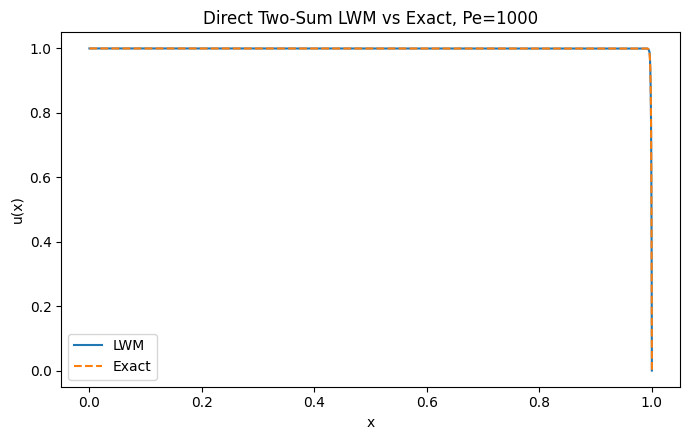

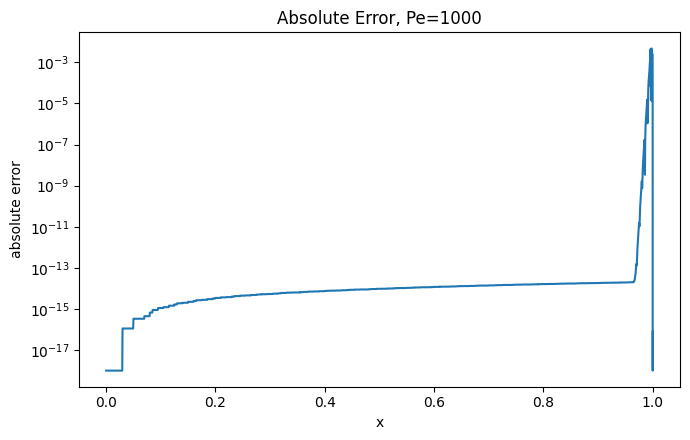


Final Summary
Pe        nu        J      M    unknowns      cond(A)        ||Ac-b||inf    max err       mean err      RMS err       L2 err
    1.0         1      4      6        24   2.949e+04   2.220e-16   1.056e-09   1.485e-10   2.821e-10   4.341e-10
   10.0       0.1      8      6        48   3.243e+05   1.421e-14   6.327e-06   3.779e-07   1.117e-06   1.312e-06
  100.0      0.01     40      6       240   4.458e+07   9.095e-13   2.213e-04   8.397e-06   3.218e-05   2.021e-05
 1000.0     0.001    200      6      1200   5.879e+09   2.910e-11   4.735e-03   1.708e-04   6.757e-04   2.006e-04

Saved files inside folder:
  lwm_results/

Main summary file:
  lwm_results/lwm_multiple_pe_summary.csv


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import Legendre, leggauss


# ============================================================
# Final Direct Two-Sum Legendre Wavelet Collocation Method
#
# Problem:
#   u''(x) - Pe*u'(x) = 0,   0 <= x <= 1
#   u(0) = 1, u(1) = 0
#
# Exact solution:
#   u(x) = (1 - exp(Pe*(x - 1))) / (1 - exp(-Pe))
#
# Pe = 1/nu
# Cases:
#   nu = 1, 0.1, 0.01, 0.001
#   Pe = 1, 10, 100, 1000
#
# Method:
#   Direct two-sum LWM:
#   u(x) ≈ sum_{j=0}^{J-1} sum_{m=0}^{M-1} c_{j,m} psi_{j,m}(x)
#
# System:
#   residual equations per cell = M - 2
#   boundary equations          = 2
#   interface equations         = 2(J - 1)
#
# Total equations:
#   J(M - 2) + 2 + 2(J - 1) = JM
# ============================================================


# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------

PE_CASES = [
    {"Pe": 1.0,    "J": 4,   "M": 6},
    {"Pe": 10.0,   "J": 8,   "M": 6},
    {"Pe": 100.0,  "J": 40,  "M": 6},
    {"Pe": 1000.0, "J": 200, "M": 6},
]

U_LEFT = 1.0
U_RIGHT = 0.0

MAKE_PLOTS = True
SAVE_RESULTS = True
OUTPUT_DIR = "lwm_results"


# ============================================================
# Exact solution
# ============================================================

def exact_solution(x, Pe):
    """
    Exact solution of:
        u''(x) - Pe*u'(x) = 0,
        u(0)=1, u(1)=0.

    Stable enough for Pe = 1, 10, 100, 1000.
    """
    x = np.asarray(x, dtype=float)

    if abs(Pe) < 1.0e-14:
        return 1.0 - x

    return (1.0 - np.exp(Pe * (x - 1.0))) / (1.0 - np.exp(-Pe))


# ============================================================
# Direct Two-Sum LWM solver
# ============================================================

def solve_lwm_bvp(Pe, J, M, u_left=1.0, u_right=0.0):
    """
    Solves:
        u''(x) - Pe*u'(x) = 0,  0 <= x <= 1
        u(0)=u_left, u(1)=u_right

    using direct two-sum Legendre wavelet collocation.

    The solving logic is:
        1. local Legendre wavelet basis on each cell
        2. residual collocation at M-2 Gauss points per cell
        3. boundary condition rows
        4. interface continuity of u and u'
        5. solve the square linear system Ac=b
    """

    if M < 3:
        raise ValueError("Use M >= 3 for a second-order BVP.")

    # Legendre polynomials and derivatives on [-1, 1]
    LEG = [Legendre.basis(m) for m in range(M)]
    DLEG = [p.deriv(1) for p in LEG]
    DDLEG = [p.deriv(2) for p in LEG]

    def col_index(j, m):
        return j * M + m

    def cell_bounds(j):
        return j / J, (j + 1) / J

    def local_coordinate(x, j):
        x_left, x_right = cell_bounds(j)
        h = x_right - x_left
        return 2.0 * (x - x_left) / h - 1.0

    def active_cell(x):
        if x <= 0.0:
            return 0
        if x >= 1.0:
            return J - 1
        return min(int(np.floor(x * J)), J - 1)

    def psi_on_cell(j, m, x):
        x_left, x_right = cell_bounds(j)
        h = x_right - x_left
        z = local_coordinate(x, j)
        scale = np.sqrt((2 * m + 1) / h)
        return scale * LEG[m](z)

    def dpsi_on_cell(j, m, x):
        x_left, x_right = cell_bounds(j)
        h = x_right - x_left
        z = local_coordinate(x, j)

        scale = np.sqrt((2 * m + 1) / h)
        dz_dx = 2.0 / h

        return scale * dz_dx * DLEG[m](z)

    def ddpsi_on_cell(j, m, x):
        x_left, x_right = cell_bounds(j)
        h = x_right - x_left
        z = local_coordinate(x, j)

        scale = np.sqrt((2 * m + 1) / h)
        dz_dx = 2.0 / h

        return scale * (dz_dx ** 2) * DDLEG[m](z)

    def psi(j, m, x):
        return psi_on_cell(j, m, x) if active_cell(x) == j else 0.0

    def dpsi(j, m, x):
        return dpsi_on_cell(j, m, x) if active_cell(x) == j else 0.0

    def ddpsi(j, m, x):
        return ddpsi_on_cell(j, m, x) if active_cell(x) == j else 0.0

    def make_residual_points():
        """
        M-2 Gauss points per cell.

        This gives:
            J(M-2)
        residual equations.
        """
        z_nodes, _ = leggauss(M - 2)
        points = []

        for j in range(J):
            x_left, x_right = cell_bounds(j)
            mid = 0.5 * (x_left + x_right)
            half = 0.5 * (x_right - x_left)

            for z in z_nodes:
                points.append(mid + half * z)

        return np.array(points, dtype=float)

    def residual_row(x):
        """
        Row for:
            u''(x) - Pe*u'(x) = 0.
        """
        row = np.zeros(J * M)

        for j in range(J):
            for m in range(M):
                row[col_index(j, m)] = ddpsi(j, m, x) - Pe * dpsi(j, m, x)

        return row

    def left_boundary_row():
        """
        Row for:
            u(0) = u_left.
        """
        row = np.zeros(J * M)
        x = 0.0
        j = 0

        for m in range(M):
            row[col_index(j, m)] = psi_on_cell(j, m, x)

        return row

    def right_boundary_row():
        """
        Row for:
            u(1) = u_right.
        """
        row = np.zeros(J * M)
        x = 1.0
        j = J - 1

        for m in range(M):
            row[col_index(j, m)] = psi_on_cell(j, m, x)

        return row

    def interface_value_row(s):
        """
        Row for value continuity:
            u_{s-1}(x_s) - u_s(x_s) = 0,
        where x_s = s/J.
        """
        row = np.zeros(J * M)

        x_s = s / J
        left_cell = s - 1
        right_cell = s

        for m in range(M):
            row[col_index(left_cell, m)] = psi_on_cell(left_cell, m, x_s)
            row[col_index(right_cell, m)] = -psi_on_cell(right_cell, m, x_s)

        return row

    def interface_derivative_row(s):
        """
        Row for derivative continuity:
            u'_{s-1}(x_s) - u'_s(x_s) = 0,
        where x_s = s/J.
        """
        row = np.zeros(J * M)

        x_s = s / J
        left_cell = s - 1
        right_cell = s

        for m in range(M):
            row[col_index(left_cell, m)] = dpsi_on_cell(left_cell, m, x_s)
            row[col_index(right_cell, m)] = -dpsi_on_cell(right_cell, m, x_s)

        return row

    # --------------------------------------------------------
    # Assemble linear system
    # --------------------------------------------------------

    A_rows = []
    b_vals = []

    residual_points = make_residual_points()

    for x in residual_points:
        A_rows.append(residual_row(x))
        b_vals.append(0.0)

    A_rows.append(left_boundary_row())
    b_vals.append(u_left)

    A_rows.append(right_boundary_row())
    b_vals.append(u_right)

    for s in range(1, J):
        A_rows.append(interface_value_row(s))
        b_vals.append(0.0)

        A_rows.append(interface_derivative_row(s))
        b_vals.append(0.0)

    A = np.vstack(A_rows)
    b = np.array(b_vals, dtype=float)

    expected_shape = (J * M, J * M)

    if A.shape != expected_shape:
        raise ValueError(f"Wrong system shape: got {A.shape}, expected {expected_shape}")

    condition_number = np.linalg.cond(A)

    coeff_vector = np.linalg.solve(A, b)
    coeffs = coeff_vector.reshape(J, M)

    algebraic_residual = np.linalg.norm(A @ coeff_vector - b, ord=np.inf)

    # --------------------------------------------------------
    # Reconstructors
    # --------------------------------------------------------

    def u_lwm(x):
        total = 0.0

        for j in range(J):
            for m in range(M):
                total += coeffs[j, m] * psi(j, m, x)

        return total

    def ux_lwm(x):
        total = 0.0

        for j in range(J):
            for m in range(M):
                total += coeffs[j, m] * dpsi(j, m, x)

        return total

    def uxx_lwm(x):
        total = 0.0

        for j in range(J):
            for m in range(M):
                total += coeffs[j, m] * ddpsi(j, m, x)

        return total

    def residual_lwm(x):
        return uxx_lwm(x) - Pe * ux_lwm(x)

    return {
        "Pe": Pe,
        "J": J,
        "M": M,
        "A": A,
        "b": b,
        "coeff_vector": coeff_vector,
        "coeffs": coeffs,
        "condition_number": condition_number,
        "algebraic_residual": algebraic_residual,
        "u_lwm": u_lwm,
        "ux_lwm": ux_lwm,
        "uxx_lwm": uxx_lwm,
        "residual_lwm": residual_lwm,
        "cell_bounds": cell_bounds,
        "residual_points": residual_points,
    }


# ============================================================
# Evaluation grids
# ============================================================

def make_dense_grid(Pe):
    """
    Dense grid with extra clustering near x=1.

    The boundary layer is near x=1.
    For large Pe, a uniform grid misses the sharp layer.
    This grid keeps the paper results honest.
    """
    uniform_part = np.linspace(0.0, 1.0, 2001)

    # Points clustered near x=1:
    # x = 1 - y, where y is logarithmically spaced.
    layer_distance = np.geomspace(1.0e-14, 1.0, 5000)
    layer_part = 1.0 - layer_distance

    x_dense = np.unique(np.concatenate([uniform_part, layer_part, np.array([0.0, 1.0])]))
    x_dense = x_dense[(x_dense >= 0.0) & (x_dense <= 1.0)]
    x_dense.sort()

    return x_dense


def make_table_grid(Pe):
    """
    Table grid.

    Includes standard points and extra points near x=1.
    The standard 0.1-spaced grid alone is misleading for Pe=100 and Pe=1000.
    """
    standard = np.linspace(0.0, 1.0, 11)

    layer_points = [
        1.0 - 5.0 / Pe,
        1.0 - 2.0 / Pe,
        1.0 - 1.0 / Pe,
        1.0 - 0.5 / Pe,
        1.0 - 0.2 / Pe,
        1.0 - 0.1 / Pe,
        1.0 - 0.05 / Pe,
        1.0 - 0.01 / Pe,
        1.0,
    ]

    layer_points = np.array(layer_points, dtype=float)
    layer_points = layer_points[(layer_points >= 0.0) & (layer_points <= 1.0)]

    x_table = np.unique(np.concatenate([standard, layer_points]))
    x_table.sort()

    return x_table


# ============================================================
# Error metrics
# ============================================================

def compute_error_metrics(x_dense, u_num, u_exact):
    abs_error = np.abs(u_num - u_exact)

    max_error = np.max(abs_error)
    mean_error = np.mean(abs_error)
    rms_error = np.sqrt(np.mean(abs_error ** 2))

    # Continuous L2-type error using trapezoidal integration
    l2_error = np.sqrt(np.trapz(abs_error ** 2, x_dense))

    return {
        "abs_error": abs_error,
        "max_error": max_error,
        "mean_error": mean_error,
        "rms_error": rms_error,
        "l2_error": l2_error,
    }


# ============================================================
# Main run
# ============================================================

def main():
    if SAVE_RESULTS:
        os.makedirs(OUTPUT_DIR, exist_ok=True)

    summary_rows = []

    for case in PE_CASES:
        Pe = float(case["Pe"])
        J = int(case["J"])
        M = int(case["M"])
        nu = 1.0 / Pe

        print("\n============================================================")
        print(f"Running Direct Two-Sum LWM for Pe={Pe:g}, nu={nu:g}")
        print("============================================================")

        sol = solve_lwm_bvp(
            Pe=Pe,
            J=J,
            M=M,
            u_left=U_LEFT,
            u_right=U_RIGHT,
        )

        u_lwm = sol["u_lwm"]
        residual_lwm = sol["residual_lwm"]
        condition_number = sol["condition_number"]
        algebraic_residual = sol["algebraic_residual"]

        # ----------------------------------------------------
        # Dense-grid evaluation
        # ----------------------------------------------------

        x_dense = make_dense_grid(Pe)

        u_dense = np.array([u_lwm(float(x)) for x in x_dense])
        u_exact_dense = exact_solution(x_dense, Pe)

        metrics = compute_error_metrics(x_dense, u_dense, u_exact_dense)

        abs_error_dense = metrics["abs_error"]
        max_dense_error = metrics["max_error"]
        mean_dense_error = metrics["mean_error"]
        rms_dense_error = metrics["rms_error"]
        l2_dense_error = metrics["l2_error"]

        left_boundary_error = abs(u_lwm(0.0) - U_LEFT)
        right_boundary_error = abs(u_lwm(1.0) - U_RIGHT)

        # Differential residual diagnostic on dense grid
        # This is NOT the main collocation residual.
        dense_residual_values = np.array([
            abs(residual_lwm(float(x)))
            for x in x_dense
            if 0.0 < x < 1.0
        ])

        max_dense_differential_residual = np.max(dense_residual_values)

        # ----------------------------------------------------
        # Print main details
        # ----------------------------------------------------

        print(f"Pe                         = {Pe:g}")
        print(f"nu                         = {nu:g}")
        print(f"J cells                    = {J}")
        print(f"M modes/cell               = {M}")
        print(f"Unknowns J*M               = {J * M}")
        print(f"Condition number cond(A)   = {condition_number:.4e}")
        print(f"Algebraic residual ||Ac-b||inf = {algebraic_residual:.4e}")

        print("\nDense-grid error metrics")
        print(f"Maximum absolute error     = {max_dense_error:.4e}")
        print(f"Mean absolute error        = {mean_dense_error:.4e}")
        print(f"RMS error                  = {rms_dense_error:.4e}")
        print(f"L2-type error              = {l2_dense_error:.4e}")
        print(f"Left boundary error        = {left_boundary_error:.4e}")
        print(f"Right boundary error       = {right_boundary_error:.4e}")
        print(f"Max dense differential residual = {max_dense_differential_residual:.4e}")

        # ----------------------------------------------------
        # Table grid
        # ----------------------------------------------------

        x_table = make_table_grid(Pe)
        table_rows = []

        print("\nTable: LWM vs Exact")
        print("x              LWM solution          Exact solution        Absolute error")

        for x in x_table:
            numerical = u_lwm(float(x))
            exact = float(exact_solution(x, Pe))
            error = abs(numerical - exact)

            table_rows.append([x, numerical, exact, error])

            print(
                f"{x: .10f}     "
                f"{numerical: .12e}     "
                f"{exact: .12e}     "
                f"{error: .4e}"
            )

        table_rows = np.array(table_rows, dtype=float)

        # ----------------------------------------------------
        # Save results
        # ----------------------------------------------------

        tag = f"pe{int(Pe)}"

        if SAVE_RESULTS:
            dense_rows = np.column_stack([
                x_dense,
                u_dense,
                u_exact_dense,
                abs_error_dense,
            ])

            np.savetxt(
                os.path.join(OUTPUT_DIR, f"lwm_{tag}_dense.csv"),
                dense_rows,
                delimiter=",",
                header="x,u_lwm,u_exact,absolute_error",
                comments="",
            )

            np.savetxt(
                os.path.join(OUTPUT_DIR, f"lwm_{tag}_table.csv"),
                table_rows,
                delimiter=",",
                header="x,u_lwm,u_exact,absolute_error",
                comments="",
            )

            np.savetxt(
                os.path.join(OUTPUT_DIR, f"lwm_{tag}_coefficients.csv"),
                sol["coeffs"],
                delimiter=",",
                header="Rows are cells j, columns are local Legendre modes m",
                comments="",
            )

        # ----------------------------------------------------
        # Plots
        # ----------------------------------------------------

        if MAKE_PLOTS:
            plt.figure(figsize=(7, 4.5))
            plt.plot(x_dense, u_dense, label="LWM")
            plt.plot(x_dense, u_exact_dense, "--", label="Exact")
            plt.xlabel("x")
            plt.ylabel("u(x)")
            plt.title(f"Direct Two-Sum LWM vs Exact, Pe={Pe:g}")
            plt.legend()
            plt.tight_layout()

            if SAVE_RESULTS:
                plt.savefig(
                    os.path.join(OUTPUT_DIR, f"lwm_{tag}_solution.png"),
                    dpi=300,
                    bbox_inches="tight",
                )

            plt.show()

            plt.figure(figsize=(7, 4.5))
            plt.semilogy(x_dense, abs_error_dense + 1.0e-18)
            plt.xlabel("x")
            plt.ylabel("absolute error")
            plt.title(f"Absolute Error, Pe={Pe:g}")
            plt.tight_layout()

            if SAVE_RESULTS:
                plt.savefig(
                    os.path.join(OUTPUT_DIR, f"lwm_{tag}_error.png"),
                    dpi=300,
                    bbox_inches="tight",
                )

            plt.show()

        # ----------------------------------------------------
        # Summary row
        # ----------------------------------------------------

        summary_rows.append([
            Pe,
            nu,
            J,
            M,
            J * M,
            condition_number,
            algebraic_residual,
            max_dense_error,
            mean_dense_error,
            rms_dense_error,
            l2_dense_error,
            left_boundary_error,
            right_boundary_error,
            max_dense_differential_residual,
        ])

    # ========================================================
    # Final summary table
    # ========================================================

    summary_rows = np.array(summary_rows, dtype=float)

    print("\n============================================================")
    print("Final Summary")
    print("============================================================")
    print(
        "Pe        nu        J      M    unknowns      cond(A)        "
        "||Ac-b||inf    max err       mean err      RMS err       L2 err"
    )

    for row in summary_rows:
        (
            Pe,
            nu,
            J,
            M,
            unknowns,
            condA,
            alg_res,
            max_err,
            mean_err,
            rms_err,
            l2_err,
            left_bc_err,
            right_bc_err,
            max_dense_res,
        ) = row

        print(
            f"{Pe:7.1f}  "
            f"{nu:8.4g}  "
            f"{int(J):5d}  "
            f"{int(M):5d}  "
            f"{int(unknowns):8d}  "
            f"{condA: .3e}  "
            f"{alg_res: .3e}  "
            f"{max_err: .3e}  "
            f"{mean_err: .3e}  "
            f"{rms_err: .3e}  "
            f"{l2_err: .3e}"
        )

    if SAVE_RESULTS:
        summary_path = os.path.join(OUTPUT_DIR, "lwm_multiple_pe_summary.csv")

        np.savetxt(
            summary_path,
            summary_rows,
            delimiter=",",
            header=(
                "Pe,nu,J,M,unknowns,condition_number,"
                "algebraic_residual_inf,max_absolute_error,"
                "mean_absolute_error,rms_error,l2_error,"
                "left_boundary_error,right_boundary_error,"
                "max_dense_differential_residual"
            ),
            comments="",
        )

        print("\nSaved files inside folder:")
        print(f"  {OUTPUT_DIR}/")
        print("\nMain summary file:")
        print(f"  {summary_path}")


if __name__ == "__main__":
    main()